# Computer Vision Vorlesung – Übungsblatt 1
**Universität Osnabrück | Sommersemester 2026**

---

Dieses Übungsblatt ist in drei Teile gegliedert:

- **Teil 0 (Aufgaben 0.1 - 0.5):** Mit diesen Aufgaben schließen wir die Einführung in `numpy` ab.
- **Teil 1 (Aufgaben 2–3):** Gauß-Filter von Grund auf implementieren
- **Teil 2 (Aufgaben 4–6):** Kantendetektion mit Gradient und dessen Richtung, Laplacian of Gaussian (LoG) und Canny

**Voraussetzung:** Übungsblatt 0 (Python-Grundlagen, NumPy-Einstieg).
Dieses Blatt baut gezielt auf den dort eingeführten Konzepten auf
und erweitert sie um mehrdimensionale Arrays und Bildverarbeitung.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import convolve

---

# Aufgabe 0: NumPy-Werkzeuge – Warm-up

Bevor wir mit der eigentlichen Bildverarbeitung beginnen, üben wir
die NumPy\-Funktionen, die in dieser Veranstaltung immer wieder auftauchen.
Arbeiten Sie die folgenden Teilaufgaben der Reihe nach durch.

> **Hinweis**  
> In Übungsblatt 0 haben Sie 1D-Arrays und grundlegende Operationen kennengelernt.
> Bilder sind jedoch **2D-Arrays** (oder sogar 3D bei Farbbildern).
> Die folgenden Funktionen werden benötigt, um mit solchen Arrays zu arbeiten.



---

## Aufgabe 0.1: `np.arange` und `np.reshape`

`np.arange(start, stop, step)` erstellt eine 1D-Sequenz – ähnlich wie Pythons `range`,
aber als NumPy-Array. Mit `.reshape(zeilen, spalten)` können Sie ein 1D-Array
in eine 2D-Matrix umformen.

**a)** Erstellen Sie ein NumPy Array, indem Sie eine Liste `bsp_liste` als Argument mit der Funktion `np.array()` aufrufen.

In [3]:
bsp_liste = [1,2,3,4]# Liste erstellen

# --------------------------------
bsp_liste_als_np_arr = np.array(bsp_liste) # liste in ein numpy array konvertieren

print(bsp_liste_als_np_arr)

[1 2 3 4]



**b\)** Erstellen Sie mit `np.arange` ein Array mit den Werten `[-2, -1, 0, 1, 2]`. Geben Sie das Array mit der `print`-Funktion aus.

In [7]:
a = np.arange(-2,3,1)
print(a)

[-2 -1  0  1  2]


**c)** Formen Sie das Array `[0, 1, 2, 3, 4, 5, 6, 7]` in eine $2 \times 4$-Matrix $A$ um. Geben Sie die Matrix mit einem `print`-Kommando aus.

**Frage:** Was fällt ihnen auf: In welcher Reihenfolge stehen die Einträge in der Matrix $A$?

In [8]:
A = np.arange(0,8,1).reshape(2,4)
print(A)

[[0 1 2 3]
 [4 5 6 7]]


**d)** Formen Sie `np.arange(8)` nun zunächst in eine $4 \times 2$-Matrix $B$ um und transponieren Sie das Ergebnis anschließend mit `np.transpose()`. Geben Sie die Matrix $B$ mit `print` aus. Welchen Shape hat die resultierende Matrix? Vergleichen Sie sie 
mit Matrix $A$ aus Aufgabe **c)** - sind die Matrizen identisch? Falls ja, warum? Falls nein, worin unterscheiden sie sich?

In [11]:
# TODO 
B = np.arange(8)

print(B)# Ausgabe B

B = B.reshape(4,2)
print(B) 
B =B.transpose()
print(B)

print(A)
... # Vergleich von A und B


[0 1 2 3 4 5 6 7]
[[0 1]
 [2 3]
 [4 5]
 [6 7]]
[[0 2 4 6]
 [1 3 5 7]]
[[0 1 2 3]
 [4 5 6 7]]


Ellipsis

---

## Aufgabe 0.2: Das `axis`-Argument – Summe über Zeilen oder Spalten

Viele NumPy-Funktionen wie `np.sum`, `np.max`, `np.mean` akzeptieren ein
`axis`-Argument. Es gibt an, **entlang welcher Achse** (z.B. zeilen- oder spaltenweise) die Funktion angewendet wird. Dabei wird über diese Achse aggregiert, so dass das Ergebnis eine Dimension weniger als das ursprüngliche Array hat.

In [12]:
M = np.arange(6).reshape(2, 3)
print(f"{M}")
print(f"\nShape = {M.shape}")

[[0 1 2]
 [3 4 5]]

Shape = (2, 3)


<ul>
    <li><code>axis=0</code> bedeutet: Rechne <b>spaltenweise </b> (entlang der ersten Achse), d.h. über alle Zeilen hinweg. Die Zeilendimension verschwindet im Ergebnis - aus Shape <code>(2, 3)</code> wird <code>(3,)</code></li>
    <li><code>axis=1</code> bedeutet: Rechne <b>zeilenweise</b>  (entlang der zweiten Achse), d.h. über alle Spalten hinweg. Die Spaltendimension verschwindet im Ergebnis - aus Shape <code>(2, 3)</code> wird <code>(2,)</code></li>
</ul>

**Beispiel (`np.sum` mit `axis=0`)**:
| | Spalte 0 | Spalte 1 | Spalte 2 |
|---|---|---|---|
| Zeile 0 | 0 | 1 | 2 |
| Zeile 1 | 3 | 4 | 5 |
| **Summe** | **3** | **5** | **7** |

**Achtung:** 

In der Vorlesung beschreiben wir ein Bild als Funktion $I(x, y)$, wobei $(x, y)$ die Pixelpositionen (Spalte, Zeile) angibt.

In Numpy werden Bilder jedoch als Matrizen gespeichert. Der Zugriff erfolgt daher über `M[row, col]`.

Daher gilt:<br>
	 - `row` entspricht der $y$-Koordinate<br>
	 - `col` entspricht der $x$-Koordinate<br>

Daher entspricht ein Pixel $I(x,y)$ in Numpy dem Zugriff `M[y, x]`.

<!--- Alte Version
Beim Zugriff auf die Matrix $M$ ist der erste Index der Zeilenindex und der zweite Index der Spaltenindex. Im Gegensatz zur Betrachtung in der Vorlesung von Bildern $I(x,y)$ als Funktionen arbeiten wir mit der Matrix in der Pixelkoordinate $(x,y)$ durch den Zugriff auf $M[y,x]$.
-->

**Aufgabe**: Gegeben die Matrix M, berechnen Sie 

- die Spaltensumme (Ergebnis: 1D-Array der Form (3,)
- die Zeilensumme (Ergebnis: 1D-Array der Form (2,)
- die Gesamtsumme (Ergebnis: Skalar)

In [19]:
M = np.array([[1, 2, 3],
              [4, 5, 6]], dtype=np.int64)

# TODO: Spaltensummen
spalten_summen = M.sum(axis=0)

# TODO: Zeilensummen 
zeilen_summen = M.sum(axis=1)

# TODO: Gesamtsummemm
gesamt = M.sum(axis=0).sum(axis=0)

print('Spaltensummen:', spalten_summen)
print('Zeilensummen: ', zeilen_summen)
print('Gesamt:       ', gesamt)

Spaltensummen: [5 7 9]
Zeilensummen:  [ 6 15]
Gesamt:        21


In [17]:
# --- Test 0.2 ---
assert list(spalten_summen) == [5, 7, 9],  f"Spaltensummen: {spalten_summen}"
assert list(zeilen_summen)  == [6, 15],     f"Zeilensummen: {zeilen_summen}"
assert gesamt == 21.,                          f"Gesamt: {gesamt}"
print('✅ 0.2 korrekt!')

✅ 0.2 korrekt!


---
## Aufgabe 0.3: `axis` bei 3D-Arrays

Ein Graustufenbild wird als 2D-Array `(H, W)` dargestellt. Ein Farbbild mit `C` Kanälen besteht aus mehreren solcher 2D-Arrays, die zu  einem 3D-Array `(H, W, C)` zusammengefasst werden.  Ein RGB-Bild hat beispielsweise 3 Farbkanäle und damit die Form `(H, W, 3)`.

In [20]:
A = np.array([
    [[-1, -1], [-1, 0], [-1, 1]],
    [[0, 1], [0, 0], [0, 1]],
    [[1, 1], [1, 0], [1, 1]]
], dtype=np.int8)

print(f'A.shape: {A.shape}')
print(f'A[0, 0] = {A[0, 0]}')

A.shape: (3, 3, 2)
A[0, 0] = [-1 -1]


**Aufgabe:** Gegeben das `(3, 3, 2)`-Array `A`, berechnen Sie
die Summe entlang der letzten Achse. Das Ergebnis hat die Form `(3, 3)`.

**Hinweis:** `axis=-1` ist eine praktische Abkürzung für die **letzte Achse**.
Bei einem `(H, W, 3)`-Array ist das identisch mit `axis=2`.

In [24]:
# TODO: Summe entlang der letzten Achse berechnen
A_sum = A.sum(axis=-1)
print(f'A_sum = {A_sum}')
print(f'Typ: {A_sum.shape}')

A_sum = [[-2 -1  0]
 [ 1  0  1]
 [ 2  1  2]]
Typ: (3, 3)


In [26]:
# --- Test 0.3 ---
assert A_sum is not None
assert A_sum.shape == (3, 3)
assert A_sum[1, 1] == 0          
assert A_sum[0, 0] == -2              
assert A_sum[0, 1] == -1              
print('✅ 0.3 korrekt!')

✅ 0.3 korrekt!


---
## Aufgabe 0.4: `np.meshgrid` – 2D-Koordinatengitter

In der Bildverarbeitung arbeiten wir häufig mit 2D-Koordinaten: jeder Pixel hat eine Position $(x, y)$ und viele Operationen müssen für alle Positionen gleichzeitig ausgewertet werden. Ein Beispiel ist die Berechnung des Abstands jedes Pixels vom Bildzentrum (dies wird in einer späteren Aufgabe erneut aufgegriffen).

Die Funktion `np.meshgrid` erzeugt aus zwei 1D-Sequenzen $\mathbf{a}$ und $\mathbf{b}$ alle Kombinationen ihrer Werte. Dies entspricht dem **kartesischen Produkt** $\mathbf{a} \times \mathbf{b}$ wobei wir  $\mathbf{a}$ und $\mathbf{b}$ jeweils als Menge auffassen. Das Ergebnis sind zwei 2D-Arrays gleicher Form: das erste Array  `X` enthält die $x$-Koordinaten, das zweite Array `Y` die $y$-Koordinaten. Die Elemente an denselben Position `(X[i, j], Y[i, j])`  in den beiden Arrays zusammen bilden ein Koordinatenpaar $(x, y)$.

**Funktionsweise:**

In [41]:
a = np.array([1, 2, 3])     # 3 Werte
b = np.array([10, 20])      # 2 Werte
X, Y = np.meshgrid(a, b)  # X und Y haben beide Form (2, 3)

print(f"X, shape={X.shape}:\n{X}\n")
print(f"Y, shape={Y.shape}:\n{Y}")

X, shape=(2, 3):
[[1 2 3]
 [1 2 3]]

Y, shape=(2, 3):
[[10 10 10]
 [20 20 20]]


Zwei Einträge `X[i,j]` und `Y[i, j]` bilden zusammen das Koordinatenpaar an Position $(i, j)$. Zum Beispiel ist `(X[1,2], Y[1, 2]) = (3, 20)` - eine der 6 möglichen Kombinationen aus `x` und `y`. Jede Kombination tritt genau einmal auf.

`X` wiederholt die $x$-Werte zeilenweise, `Y` die $y$-Werte spaltenweise - so werden alle $2 \times 3 = 6$ Kombinationen abgedeckt.

**Aufgabe:** Erstellen Sie mit `np.meshgrid` zwei 2D-Arrays `X` und `Y`,
die für jede Position im $3 \times 3$-Gitter die $x$- bzw. $y$-Koordinate enthalten.
Verwenden Sie in beide Richtungen die Koordinaten `[-1, 0, 1]`.

In [28]:
# TODO: Kooridnaten für x und x Richtung
coords_1d = [-1,0,1]

# TODO: 2D-Arrays X,Y mit np.meshgrid aus coords_1d
X, Y = np.meshgrid(coords_1d,coords_1d)

print(f"X (x-Koordinaten), shape={X.shape}:\n{X}\n")
print(f"Y (y-Koordinaten), shape={Y.shape}:\n{Y}")

X (x-Koordinaten), shape=(3, 3):
[[-1  0  1]
 [-1  0  1]
 [-1  0  1]]

Y (y-Koordinaten), shape=(3, 3):
[[-1 -1 -1]
 [ 0  0  0]
 [ 1  1  1]]


In [29]:
# --- Test 0.4 ---
assert X is not None and Y is not None
assert X.shape == (3, 3),     f"Form sollte (3,3) sein"
assert Y.shape == (3, 3)
assert list(X[0]) == [-1., 0., 1.],   "Erste Zeile von X: [-1, 0, 1]"
assert list(X[1]) == [-1., 0., 1.],   "Zweite Zeile von X: [-1, 0, 1]"
assert list(Y[:, 0]) == [-1., 0., 1.], "Erste Spalte von Y: [-1, 0, 1]"
print('✅ 0.4 korrekt!')

✅ 0.4 korrekt!


---
## Aufgabe 0.5: `np.stack` – Arrays zusammenlegen

In Aufgabe 0.4 haben wir zwei separate Arrays `X` und `Y` erhalten, die zusammen die Koordinaten jedes Gitterpunkts beschreiben. Oft möchten wir jedoch nicht mit zwei getrennten Arrays arbeiten, sondern die Koordinaten pro Punkt direkt gemeinsam betrachten:

`grid[i, j] = [x, y]`

Ein naiver Ansatz ist es, ein leeres Array zu initialisieren und die Werte per Schleife einzutragen.

In [30]:
# Leeres Array für die Koordinaten (x, y) erstellen

num_rows, num_cols = X.shape # Anzahl Zeilen und Spalten
new_shape = (num_rows, num_cols, 2) # zusätzliche Dimension für die Koordinaten

grid = np.zeros(shape=new_shape, dtype=int) # Form (3, 3, 2)
print(f"Form des Gitters: {grid.shape}")
print(f"Gitter mit Nullen: \n {grid}")

Form des Gitters: (3, 3, 2)
Gitter mit Nullen: 
 [[[0 0]
  [0 0]
  [0 0]]

 [[0 0]
  [0 0]
  [0 0]]

 [[0 0]
  [0 0]
  [0 0]]]


In [11]:
# Befüllen mit Koordinatenwerten
for i in range(X.shape[0]):
    for j in range(Y.shape[1]):
        grid[i, j] = [X[i, j], Y[i, j]]
print(grid, "\n")  # rohe Darstellung (3D-Array) 

# Darstellung als Koordinatengitter (x,y)
for row in grid:
    print([tuple(map(int, p)) for p in row])

NameError: name 'X' is not defined

NumPy bietet dafür eine elegantere Lösung: `np.stack` kombiniert mehrere Arrays gleicher Form entlang einer **neuen** Achse - in einer einzigen Zeile und ohne explizite Schleifen.

In [32]:
grid = np.stack([X, Y], axis=2)
print(f"Gitter: {grid}")

Gitter: [[[-1 -1]
  [ 0 -1]
  [ 1 -1]]

 [[-1  0]
  [ 0  0]
  [ 1  0]]

 [[-1  1]
  [ 0  1]
  [ 1  1]]]


**Aufgabe**: Betrachten Sie die erste Zeile des aktuellen Gitter `grid`, also `grid[0]`. Diese enthält die Koordinaten ` [-1, -1], [0, -1], [1, -1]]`. Hier entspricht die Darstellung der Konvention `[x, y]`. In NumPy werden Bildkoordinaten üblicherweise als `(y,x)` adressiert. Daher passen wir die Darstellung im Gitter an diese Konvention an, indem das erste Elemente den Zeilenindex (also die $y$-Koordinate) beschreibt. Verändern Sie den `stack` Aufruf so, das gilt `grid[i,j]=[y,x]`. Überprüfen Sie, dass die erste Zeile des Gitters dann `grid[0]=[[-1, -1], [-1, 0], [-1, 1]]` entspricht.

<!--
dass stattdessen der Zeilenindex als erstes Element auftaucht, sprich `grid[0]=[[-1, -1], [-1, 0], [-1, 1]]` für die erste Zeile. -->

In [12]:
# TODO: Stapeln Sie X und Y zu einem (3, 3, 2)-Array
grid = np.stack([Y,X],axis=2)


print('grid.shape:', grid.shape)
print('grid[0, 0] =', grid[0, 0], '  <- sollte [-1, -1] sein')
print('grid[1, 1] =', grid[1, 1], '  <- sollte [ 0,  0] sein')
print('grid[2, 2] =', grid[2, 2], '  <- sollte [ 1,  1] sein')

NameError: name 'Y' is not defined

In [42]:
# --- Test 0.5 ---
assert grid is not None
assert grid.shape == (3, 3, 2),         f"Form sollte (3,3,2) sein, ist {grid.shape}"
assert list(grid[0, 0]) == [-1, -1],  f"grid[0,0] = {list(grid[0,0])}"
assert list(grid[1, 1]) == [ 0,  0],  f"grid[1,1] = {list(grid[1,1])}"
assert list(grid[0, 2]) == [-1,  1],  f"grid[0,2] = {list(grid[0,2])}"
print('✅ 0.5 korrekt!')

✅ 0.5 korrekt!


## 📢 Werkzeugkasten komplett - ab jetzt: Dokumentation lesen
Sie haben nun die wichtigsten Numpy-Bausteine kennengelernt, die in den Übungsaufgaben immer wieder auftauchen werden: `slicing`, `np.arange`, `np.stack`, `reshape`, das `axis`-Argument, `np.meshgrid` und `np.stack`.

Numpy bietet darüber hinaus hunderte weitere Funktionen - und niemand kennt sie alle auswendig. Eine zentrale Kompetenz in der wissenschaftlichen Programmierung ist es, die **offizielle Dokumentation** geziel zu nutzen:<br>
👉 [https://numpy.org/doc/stable/reference/]

Wenn Sie in den folgenden Übungsblättern auf eine unbekannte Funktion stoßen oder eine bestimmte Operation ausführen möchten, schauen Sie dort nach. Die Dokumentation enthält für jede Funktion eine Beschreibung, die Signatur mit allen Parametern und konkrete Beispielen.

Ab sofort werden neue NumPy-Funktionen nicht mehr gesondert eingeführt.

---
# Teil 1: Der Gauß-Filter

Stellen Sie sich vor, ein Bild enthält **Rauschen**: einzelne Pixel weichen zufällig
von ihrem tatsächlichen Wert ab. Ein naheliegender Ansatz zur Reduktion dieses Rauschens besteht darin, jeden Pixel durch den **Durchschnitt seiner Nachbarschaft** zu ersetzen.

Ein solcher Ansatz kann das Rauschen reduzieren. Allerdings werden alle Nachbarn gleich gewichtet, unabhängig davon, wie weit sie vom betrachteten Pixel entfernt sind.

Darüber hinaus enthalten Bilder Strukturen auf unterschiedlichen **Skalen**, z.B. feine Details wie Texturen oder grobe Strukturen wie Objekte.

Eine einfache Mittelung behandelt alle Strukturen gleich und kann daher wichtige Details verwischen.

**Intuitiv** wäre es daher sinnvoller einen Kernel zu verwenden, beim dem

- der Pixel selbst das **größte** Gewicht hat,
- direkte Nachbarn **weniger** Einfluss haben,
- weiter entfernte Nachbarn **noch weniger** Einfluss haben.

In der Vorlesung haben Sie bereits einen solchen Kernel kennen gelernt: den **Gauß-Kernel**. In den folgenden Aufgaben werden wir diesen diskreten Kernel konstruieren und untersuchen.


## Aufgabe 1: Motivation – Warum glätten?

**Aufgabe 1.1:** Beobachtung von Rauschen.
Betrachten Sie zunächst die folgenden Bilder (Original und mit synthetischem Rauschen).
Führen Sie die nachfolgende Zelle aus und beschreiben Sie in der Markdown-Zelle darunter,
was Sie beim Vergleich der Bilder beobachten.

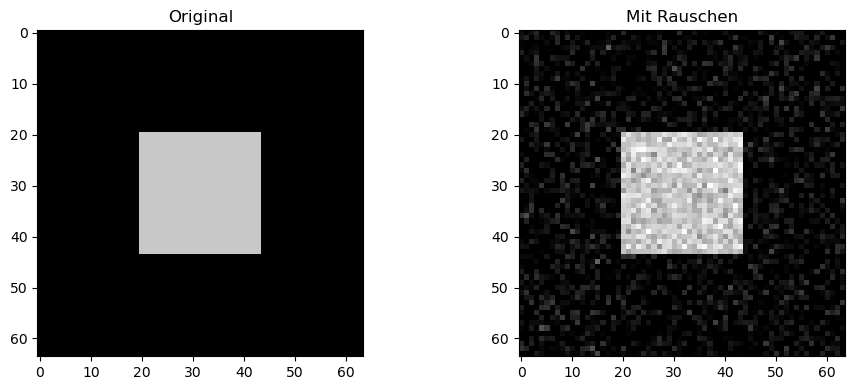

In [37]:
# Synthetisches Bild erzeugen
bild_sauber = np.zeros((64, 64), dtype=np.float64)
bild_sauber[20:44, 20:44] = 200.0  # helles Quadrat

# Verrauschte Variante erzeugen
np.random.seed(42)
rauschen = np.random.normal(loc=0, scale=25, size=bild_sauber.shape)
bild_verrauscht = np.clip(bild_sauber + rauschen, 0, 255)

# Visualisieren
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(bild_sauber,     cmap='gray', vmin=0, vmax=255)
axes[0].set_title('Original')
axes[1].imshow(bild_verrauscht, cmap='gray', vmin=0, vmax=255)
axes[1].set_title('Mit Rauschen')
plt.tight_layout()
plt.show()

Um Ihre Beobachtungen zu beschreiben könnten Sie sich folgende Fragen stellen: 
- Wie äußert sich das Rauschen räumlich und visuell?
- Welche Struktur bleibt trotz Rauschen git erkennbar? 
- (Warum könnte eine Mittelung helfen das Rauschen zu reduzieren?)

---

### Aufgabe 1.2: Das lokale Koordinatengitter

Um einen Filter wie den Gauß-Kernel zu definieren, müssen wir festlegen, wie stark Pixel in der Umgebung eines Punktes gewichtet werden. Diese Gewichtung hängt davon ab, **wo** sich ein Pixel relativ zum Zentrum befindet. Dazu führen wir ein lokales **Koordinatengitter**  ein. Das Zentrum eines Kernels der Größe $n \times n$ liegt bei $(0, 0)$. Jede Position $(x,y)$ im Kernel wird relativ zu diesem Zentrum angegeben.  

Für einen $3 \times 3$-Kernel ergibt sich folgendes Gitter:


$$
\mathcal{N} = \begin{pmatrix}
(1,1) & (0,1) & (-1,1) \\
(1,0) & (0,0) & (-1,0) \\
(1,-1) & (0,-1) & (-1,-1)
\end{pmatrix}
$$


Dieses Gitter haben wir schon in Aufgabe 0.5 beim explorieren der `stack`-Funktion gesehen.

In Vorlesung 2  wurde die Faltung eines Bildes $I$ mit einem Kernel $h$ als gewichtete Summe über eine lokale Nachbarschaft definiert:

$$
g(i,j) = \sum_{k=-r}^r \sum_{l= -s}^s I( i - k, j - l) h(k, l).
$$
Das Zentrum ist durch die aktuelle Pixelposition $(i,j$) festgelegt und die Indizes $k$ und $l$ beschreiben dabei **relative Positionen** zu diesem Zentrum. Die Werte $r, s \in \N$, die die Größe der betrachteten Nachbarschaft festlegen, werden als **Offsets** bezeichnet.
Für einen $3 \times 3$- Kernel gilt $r = s =1$, sodass die Summen über $-1, 0, 1$ laufen. Dies entspricht genau den Werten des Koordinatengitters. Das Koordinatengitter beschreibt also genau die relativen Positionen, an denen der Kernel in der Faltung ausgewertet wird.



**Aufgabe:** Schreiben Sie die Funktion `make_grid(n)`, die ein solches Koordinatengitter erzeugt. Das Ergebnis soll ein  Array der Form `(n, n, 2)` sein, sodass gilt:  `grid[i, j] = [y, x]` wobei $(y, x)$ die Koordinaten relativ zum Zentrum darstellen.

*Hinweis:* 

a) Sie haben alle nötigen Bausteine in Teil 0 geübt: Mit
`np.arange(-offset, offset+1)` erzeugen Sie den Koordinatenvektor, mit  `np.meshgrid` das 2D-Gitter und mit `np.stack([..., ...], axis=-1)` fassen Sie die Koordinaten zusammen. Der Offset vom Zentrum beträgt `n // 2`.

b) Die Matrix $\mathcal{N}$ muss in `python` transponiert gespeichert werden, vergleiche Aufgabe 0.5.



In [4]:
def make_grid(n: int) -> np.ndarray:
    """
    Erstellt ein Koordinatengitter der Größe n x n.

    Parameters:
        n: Kernelgröße (ungerade, z.B. 3, 5, 7).

    Returns:
        Array der Form (n, n, 2), wobei grid[i,j] = [y, x].
    """
    offset = n // 2
    # TODO: Koordinatenvektor [-offset, ..., 0, ..., +offset]
    coords = np.arange(-offset,offset+1)
    print(coords)
    # TODO: 2D-Gitter mit np.meshgrid
    XX, YY = np.meshgrid(coords,coords)
    # TODO: zu einem (n, n, 2)-Array zusammenfügen, sodass grid[i,j] = [y, x]
    return np.stack([YY,XX],axis=2)

# Ausgabe zur Kontrolle
grid = make_grid(3)
print('Form:', grid.shape)
print(f'Gitter: \n', grid)

[-1  0  1]
Form: (3, 3, 2)
Gitter: 
 [[[-1 -1]
  [-1  0]
  [-1  1]]

 [[ 0 -1]
  [ 0  0]
  [ 0  1]]

 [[ 1 -1]
  [ 1  0]
  [ 1  1]]]


In [34]:
# --- Test 1.2 ---
g = make_grid(3)
assert g.shape == (3, 3, 2),          f"Form sollte (3,3,2) sein, ist {g.shape}"
assert list(g[0, 0]) == [-1, -1],     f"g[0,0] sollte [-1,-1] sein, ist {list(g[0,0])}"
assert list(g[1, 1]) == [ 0,  0],     f"g[1,1] sollte [0,0] sein,   ist {list(g[1,1])}"
assert list(g[2, 2]) == [ 1,  1],     f"g[2,2] sollte [1,1] sein,   ist {list(g[2,2])}"
assert list(g[0, 2]) == [-1,  1],     f"g[0,2] sollte [-1,1] sein,  ist {list(g[0,2])}"

g5 = make_grid(5)
assert g5.shape == (5, 5, 2)
assert list(g5[0, 0]) == [-2, -2]
assert list(g5[4, 4]) == [ 2,  2]
print('✅ make_grid korrekt!')

[-1  0  1]
[-2 -1  0  1  2]
✅ make_grid korrekt!


---

## Aufgabe 1.3: Kernel-Werte per Hand

Der Kernel, den wir verwenden, stammt aus der **Gaußschen Normalverteilung**. Für eine Position $(x, y)$ im Kernel berechnet sich das Gewicht (also der entsprechende Kernelwert) als:

$$G(x, y; \sigma) = \exp\!\left(-\frac{x^2 + y^2}{2\sigma^2}\right)$$

dabei ist $\sigma$ die **Standardabweichung** und steuert, wie schnell
die Gewichte mit der Entfernung vom Zentrum abnehmen.

**Aufgabe 1.3**  
**(a)** Berechnen Sie die Kernelgewichte,  für alle 9 Koordinaten $(x, y)$ des $3 \times 3$-Koordinatengitters als Eingabe für die Funktion $G(x,y; \sigma)$ für $\sigma = 1$. Nutzen Sie dabei, dass die Funktion nur vom Abstand zum Zentrum abhängt.
Tragen Sie Ihre Ergebnisse  (auf 4 Nachkommastellen gerundet) in die folgende Tabelle ein.


**Ihre Ergebnisse:**

Mit $\sigma = 1$ gilt $2\sigma^2 = 2$:

| $(x, y)$ | $x^2 + y^2$ | $G(x,y)$ 
|---|---|---|
| $(-1,-1)$ | 2 | e^-2/2 |
| $(-1, 0)$ | 1 | e^-1/2 |
| $(-1,+1)$ | 2 | e^-2/2 |
| $(0, -1)$ | 1 | e^-1/2 |
| $(0,  0)$ | 0 | e^-0 |
| $(0, +1)$ | 1 | e^-1/2 |
| $(+1,-1)$ | 2 | e^-2/2 |
| $(+1, 0)$ | 1 | e^-1/2 |
| $(+1,+1)$ | 2 | e^-2/2|

**Aufgabe 1.3**  
**(b) - Reflexion :** Betrachten Sie Ihre berechneten Werte aus Aufgabe 1.3 und beantworten Sie die folgenden Fragen:
1. Wie viele verschiedene Werte kommen im Kernel vor? Begründen Sie Ihre Antwort. Wovon hängt ab, ob zwei Positionen dasselbe Gewicht haben?
2. Überlegen Sie sich, wie sich die Werte des Kernels verändern, wenn Sie die Standardabweichung $\sigma$ erhöhen?

**Ihre Antworten:**

---

**Aufgabe 1.4:** Schreiben Sie nun eine Funktion `gauss_kernel(n, sigma)`,  wobei $n$ die Kernelgröße bezeichnet und $\sigma$ die Standardabweichung. Diese Funktion soll den Gaußkernel  der Größe $n \times n$  mit  **normalisierten** Einträgen (die sich zu $1$ aufsummieren)  berechnen. Verwenden Sie dafür Ihre Implementationen des Koordinatengitters `make_grid(n)`.

*Hinweis:* `np.exp(x)` berechnet $e^x$ elementweise.  
Zum Normalisieren teilen Sie durch die Gesamtsumme der Kerneleinträge. Die Nomalisierung gewährleistet, dass die Faltung gewichtete Mittelwerte berechnet.

In [32]:
def gauss_kernel(n: int, sigma: float) -> np.ndarray:
    """
    Berechnet einen normalisierten Gauß-Kernel.

    Parameters:
        n:     Kernelgröße (ungerade).
        sigma: Standardabweichung.

    Returns:
        Normalisierter Kernel als Array der Form (n, n).
    """
    grid = make_grid(n)                      # Form (n, n, 2)
    print(grid)
    # TODO: x^2 + y^2 an jeder Position berechnen
    r2 = np.zeros((n,n))
    for i in range(n):
        for j in range(n):
            y,x = grid[i,j]
            r2[i,j] = x*x+y*y
    # TODO: Gaußformel anwenden
    h = np.exp(-r2/sigma*sigma*2)
    # TODO: Normalisieren (teilen durch die Gesamtsumme)
    return h/h.sum()

# Ausgabe zur Kontrolle
h = gauss_kernel(3, sigma=1)
print('Kernel (sigma=1):')
print(np.round(h, 4))
print(f'Summe: {h.sum():.6f}')

[-1  0  1]
[[[-1 -1]
  [-1  0]
  [-1  1]]

 [[ 0 -1]
  [ 0  0]
  [ 0  1]]

 [[ 1 -1]
  [ 1  0]
  [ 1  1]]]
Kernel (sigma=1):
[[0.0113 0.0838 0.0113]
 [0.0838 0.6193 0.0838]
 [0.0113 0.0838 0.0113]]
Summe: 1.000000


In [33]:
# --- Test 1.4 ---
K = gauss_kernel(3, sigma=1)
assert K.shape == (3, 3),                      "Form sollte (3,3) sein"
assert abs(K.sum() - 1.0) < 1e-6,              "Kernel muss auf 1 normalisiert sein"
assert K[1, 1] > K[0, 1],                      "Zentrum muss größtes Gewicht haben"
assert K[0, 1] > K[0, 0],                      "Kante > Ecke"
assert abs(K[0, 0] - K[0, 2]) < 1e-10,         "Kernel muss symmetrisch sein"
assert abs(K[0, 0] - K[2, 2]) < 1e-10,         "Kernel muss symmetrisch sein"

K5 = gauss_kernel(5, sigma=2)
assert K5.shape == (5, 5)
assert abs(K5.sum() - 1.0) < 1e-6
print('✅ gauss_kernel korrekt!')

[-1  0  1]
[[[-1 -1]
  [-1  0]
  [-1  1]]

 [[ 0 -1]
  [ 0  0]
  [ 0  1]]

 [[ 1 -1]
  [ 1  0]
  [ 1  1]]]
[-2 -1  0  1  2]
[[[-2 -2]
  [-2 -1]
  [-2  0]
  [-2  1]
  [-2  2]]

 [[-1 -2]
  [-1 -1]
  [-1  0]
  [-1  1]
  [-1  2]]

 [[ 0 -2]
  [ 0 -1]
  [ 0  0]
  [ 0  1]
  [ 0  2]]

 [[ 1 -2]
  [ 1 -1]
  [ 1  0]
  [ 1  1]
  [ 1  2]]

 [[ 2 -2]
  [ 2 -1]
  [ 2  0]
  [ 2  1]
  [ 2  2]]]
✅ gauss_kernel korrekt!


---

## Den Filter anwenden

Nun wenden wir den Gauß-Kernel $h$ als **Faltung** auf das verrauschte Bild an.
Die Faltung ersetzt jeden Pixel $(i,j)$ durch die gewichtete Summe der
umliegenden Pixel gemäß den Kernelgewichten:

$$
g(i,j) = \sum_{k=-r}^r \sum_{l= -s}^s I( i - k, j - l) h(k, l).
$$

Wir verwenden dafür die Funktion [`scipy.ndimage.convolve(bild, kernel)`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.ndimage.convolve.html), die die Faltung mit Gauß-Kernel effizient umsetzt.

**Aufgabe 1.5:** In der folgenden Zelle stellen wir Ihnen Code bereit, mit dem Sie für verschiedene Werte für $\sigma$ ausprobieren können. Erstellen Sie eine Liste \(kein NumPy\-Array!\) mit Werten für $\sigma$. Wenden Sie `convolve` mit Ihrem Gauß\-Kernel auf `bild_verrauscht` aus Aufgabe 0 an. Beschreiben Sie Ihre Beobachtungen für unterschiedliche Werte für $\sigma$ und erklären Sie diese.

[-5 -4 -3 -2 -1  0  1  2  3  4  5]
[[[-5 -5]
  [-5 -4]
  [-5 -3]
  [-5 -2]
  [-5 -1]
  [-5  0]
  [-5  1]
  [-5  2]
  [-5  3]
  [-5  4]
  [-5  5]]

 [[-4 -5]
  [-4 -4]
  [-4 -3]
  [-4 -2]
  [-4 -1]
  [-4  0]
  [-4  1]
  [-4  2]
  [-4  3]
  [-4  4]
  [-4  5]]

 [[-3 -5]
  [-3 -4]
  [-3 -3]
  [-3 -2]
  [-3 -1]
  [-3  0]
  [-3  1]
  [-3  2]
  [-3  3]
  [-3  4]
  [-3  5]]

 [[-2 -5]
  [-2 -4]
  [-2 -3]
  [-2 -2]
  [-2 -1]
  [-2  0]
  [-2  1]
  [-2  2]
  [-2  3]
  [-2  4]
  [-2  5]]

 [[-1 -5]
  [-1 -4]
  [-1 -3]
  [-1 -2]
  [-1 -1]
  [-1  0]
  [-1  1]
  [-1  2]
  [-1  3]
  [-1  4]
  [-1  5]]

 [[ 0 -5]
  [ 0 -4]
  [ 0 -3]
  [ 0 -2]
  [ 0 -1]
  [ 0  0]
  [ 0  1]
  [ 0  2]
  [ 0  3]
  [ 0  4]
  [ 0  5]]

 [[ 1 -5]
  [ 1 -4]
  [ 1 -3]
  [ 1 -2]
  [ 1 -1]
  [ 1  0]
  [ 1  1]
  [ 1  2]
  [ 1  3]
  [ 1  4]
  [ 1  5]]

 [[ 2 -5]
  [ 2 -4]
  [ 2 -3]
  [ 2 -2]
  [ 2 -1]
  [ 2  0]
  [ 2  1]
  [ 2  2]
  [ 2  3]
  [ 2  4]
  [ 2  5]]

 [[ 3 -5]
  [ 3 -4]
  [ 3 -3]
  [ 3 -2]
  [ 3 -1]
  [ 3  0]
  [ 3  1]

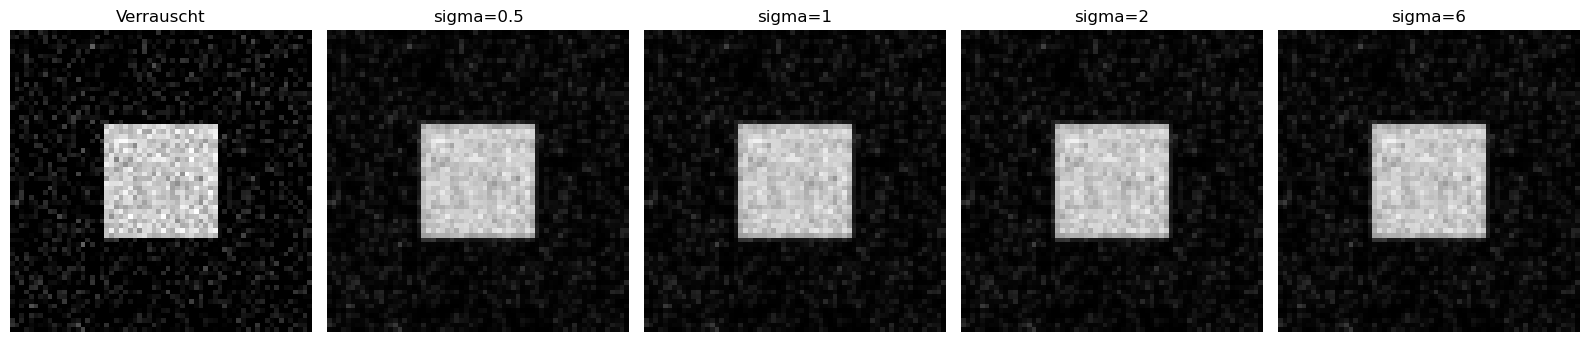

In [51]:
sigmas = [0.5,1,2,6] # TODO: Tragen Sie hier Ihre Werte für sigma ein. Die Visualisierung passt sich automatisch an diese Liste an. 
import scipy
fig, axes = plt.subplots(1, len(sigmas) + 1, figsize=(16, 4))

axes[0].imshow(bild_verrauscht, cmap='gray', vmin=0, vmax=255)
axes[0].set_title('Verrauscht')
axes[0].axis('off')

for ax, sigma in zip(axes[1:], sigmas):
    # TODO: Kernel berechnen und convolve anwenden
    kernel = gauss_kernel(10,sigma)
    gefiltertes_bild = convolve(bild_verrauscht,kernel)
    ax.imshow(gefiltertes_bild, cmap='gray', vmin=0, vmax=255)
    ax.set_title(f'sigma={sigma}')
    ax.axis('off')

plt.tight_layout()
plt.show()

---
## Aufgabe 2: Struktur des Kernels – Rang

Schauen wir uns den berechneten Kernel genauer an.

**Aufgabe 2.1:** Berechnen Sie den Gauß-Kernel für $n=3$, $\sigma=1$
und geben Sie ihn aus. Was fällt Ihnen auf, wenn Sie die Zeilen miteinander vergleichen?

In [52]:
h = gauss_kernel(3, sigma=1)
print(f'Kernel:{h}')

[-1  0  1]
[[[-1 -1]
  [-1  0]
  [-1  1]]

 [[ 0 -1]
  [ 0  0]
  [ 0  1]]

 [[ 1 -1]
  [ 1  0]
  [ 1  1]]]
Kernel:[[0.01134374 0.08381951 0.01134374]
 [0.08381951 0.61934703 0.08381951]
 [0.01134374 0.08381951 0.01134374]]


**Definition (Lineare Abhängigkeit & Rang):**

Vektoren $\mathbf{v_1}, \mathbf{v_2},...,\mathbf{v_k}$ heißen **linear abhängig**, wenn es Skalare $\lambda_1, \lambda_2, ..., \lambda_k$ gibt, die **nicht alle null** sind, sodass:
$$\sum_{i=1}^k \lambda_i \mathbf{v}_i = 0$$

Andernfalls heißen sie **linear unabhängig**. Der **Rang** einer Matrix ist die maximale Anzahl linear unabhängiger Zeilenvektoren - also die kleinste Menge an Zeilen, aus der sich alle anderen Zeilen als Linearkombination darstellen lassen.  


**Frage:** Sind die Zeilen des Gaußkernels linear abhängig oder unabhängig? Was ist der Rang des Kernels?

---

## Separierbarkeit

Der Kernel hat Rang 1, d.h. gegeben eine beliebige Zeile, lassen sich alle anderen Zeilen als Vielfache dieser einen Zeile schreiben. Das bedeutet, wir können den Kernel als äußeres Produkt zweier 1D-Vektoren schreiben:

$$\mathbf{h} =  \mathbf{v} \cdot \mathbf{w^\top}$$

wobei $\mathbf{v} \in \mathbb{R}^n$ ein Spaltenvektor und $\mathbf{w^\top} \in \mathbb{R}^m$ ein Zeilenvektor ist.

**Aufgabe 2.2:** Separieren Sie den Kernel per Hand.

1. Wählen Sie die erste Spalte des (normalisierten) Kernels als $\mathbf{v}$.  d.h. `v = h[:, 0]`.
2. Wählen Sie die erste Zeile des Kernels. Teilen Sie diese Zeile **komponentenweise** durch den skalaren Eintrag `v[0]`, d.h. `w = h[0,:]/v[0]`.
3. Überprüfen Sie mit NumPy, dass `np.outer(v, w)` den (normalisierten) Kernel rekonstruiert.

**Hinweis:** Die Wahl der Spalten und Zeilen ist beliebig — generell gilt es nur darauf zu achten, dass alle Einträge in den verwendeten Zeilen und Spalten ungleich 0 sind. Das ist im Gaußkernel stets der Fall (für moderate Kernelgrößen).

In [56]:
# Normalisierter Kernel für die Handrechnung
grid = make_grid(3)
sigma = 1.0
r2 = (grid**2).sum(axis=-1)
K_unnorm = np.exp(-r2 / (2 * sigma**2))
K = K_unnorm / np.sum(K_unnorm)
h = K
print(f'Normalisierter Kernel: \n {np.round(K, 4)} \n')

[-1  0  1]
Normalisierter Kernel: 
 [[0.0751 0.1238 0.0751]
 [0.1238 0.2042 0.1238]
 [0.0751 0.1238 0.0751]] 



In [57]:
# TODO: Extrahieren Sie v als erste Spalte (j = 0)
v = K[:,0]

# TODO: Berechnen Sie die Skalierungsfaktoren alpha_i für jede Zeile, indem Sie die erste Zeile aus dem Kernel durch den ersten Eintrag in v teilen
w = K[0,:]/v[0]

print(f'v: {np.round(v, 4)}')
print(f'w:{np.round(w, 4)} \n')
print(f'Rekonstruierter Kernel (outer(v, w)): \n {np.round(np.outer(v, w), 4)}')

v: [0.0751 0.1238 0.0751]
w:[1.     1.6487 1.    ] 

Rekonstruierter Kernel (outer(v, w)): 
 [[0.0751 0.1238 0.0751]
 [0.1238 0.2042 0.1238]
 [0.0751 0.1238 0.0751]]


In [58]:
# --- Test 2.2 ---
assert v is not None and w is not None, "v und w müssen definiert sein"
rekonstruiert = np.outer(v, w)
assert np.allclose(rekonstruiert, h, atol=1e-6), \
    f"Rekonstruktion stimmt nicht:\n{rekonstruiert}\nvs\n{h}"
print('✅ Separierung korrekt!')

✅ Separierung korrekt!


**Reflektions-Frage:** Sind die Vektoren $\mathbf{v}$ und $\mathbf{w}$ im Allgemeinen eindeutig? Begründen Sie Ihre Antwort.

**Ihre Antwort:**

----

---
# Teil 2: Kantendetektion (Bitte ab Vorlesung 3 bearbeiten)

---
## Aufgabe 3: Motivation – Wo sind die Kanten?

In Teil 1 haben Sie Bilder geglättet, um **Rauschen** zu reduzieren. Der nächste Schritt ist nun, Stellen in Bildern zu finden, an denen ein Objekt beginnt oder endet.

Solche Stellen nennen wir **Kanten** – Orte, an denen sich die Bildintensität **stark ändert**.

**Aufgabe 3.1:** Führen Sie die folgende Zelle aus. Sie sehen das Originalbild und eine geglättete Version ($\sigma=7$).
Beschreiben Sie anschließend anhand des **geglätteten Bildes**, an welchen Stellen Sie Kanten erwarten und warum.
Unterscheiden Sie dabei zwischen Kanten, die durch **Objektgrenzen**, **Schatten** oder **Textur** entstehen.

In [1]:
from skimage import data

bild_real = data.camera().astype(np.float64)   # 512×512 Graustufenfoto

# Geglättetes Bild und Gradientenbetrag vorberechnen (sigma=3, k=9)
K_vis    = gauss_kernel(9, sigma=7)
gegl_vis = convolve(bild_real, K_vis)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(bild_real,  cmap='gray', vmin=0, vmax=255)
axes[0].set_title('Original')
axes[0].axis('off')
axes[1].imshow(gegl_vis,  cmap='gray', vmin=0, vmax=255)
axes[1].set_title('Geglättet ($\sigma=7$)')
axes[1].axis('off')
plt.tight_layout()
plt.show()

NameError: name 'np' is not defined

---
## Gradient – Betrag und Richtung

Eine Kante ist mathematisch ein Ort mit großem **Gradientenbetrag**.
In der Praxis berechnen wir den Gradienten mit den **Sobel-Kerneln**:

$$S_x = \begin{pmatrix}-1 & 0 & 1 \\ -2 & 0 & 2 \\ -1 & 0 & 1\end{pmatrix}, \qquad
S_y = \begin{pmatrix}-1 & -2 & -1 \\ 0 & 0 & 0 \\ 1 & 2 & 1\end{pmatrix}$$

Aus den Komponenten $I_x$ und $I_y$ ergibt sich:

- **Gradientenbetrag:** $|\nabla I| = \sqrt{I_x^2 + I_y^2}$ – wie stark ist die Änderung?
- **Gradientenrichtung:** $\theta = \text{arctan2}(I_y, I_x)$ – in welche Richtung zeigt die stärkste Änderung?

Genau diesen dreistufigen Prozess — Glätten, Ableiten, Kanten finden — werden wir im Folgenden Schritt für Schritt selbst implementieren.

**Aufgabe 3.2:** Implementieren Sie `sobel_x(bild)` und `sobel_y(bild)`.

*Hinweis:* Nutzen Sie das bereits importierte `convolve`.

In [0]:
def sobel_x(bild: np.ndarray) -> np.ndarray:
    """
    Berechnet den Sobel-Gradienten in x-Richtung.
    """
    sobel_kernel_x = ...
    return ...

def sobel_y(bild: np.ndarray) -> np.ndarray:
    """
    Berechnet den Sobel-Gradienten in y-Richtung.
    """
    sobel_kernel_y = ...
    return ...

Ix = sobel_x(bild_real)
Iy = sobel_y(bild_real)
print(f'Ix-Form:{Ix.shape}')
print(f'Iy-Form:{Ix.shape}')

In [0]:
# --- Test 3.2 ---
test = np.zeros((7, 7), dtype=np.float64)
test[:, 3:] = 255
Ix_test = sobel_x(test)
Iy_test = sobel_y(test)
assert Ix_test.shape == test.shape
assert Iy_test.shape == test.shape
assert np.max(np.abs(Ix_test)) > 0,                               'Sobel-x sollte auf vertikale Kanten reagieren'
assert np.max(np.abs(Ix_test)) > np.max(np.abs(Iy_test)),        'Bei vertikaler Kante sollte x dominieren'
print('✅ sobel_x / sobel_y korrekt!')

**Aufgabe 3.3:** Berechnen Sie den **Gradientenbetrag** und visualisieren Sie ihn.

$$|\nabla I| = \sqrt{I_x^2 + I_y^2}$$

In [0]:
# TODO: Gradientenbetrag berechnen
grad_mag = ...

#---------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(bild_real, cmap='gray')
axes[0].set_title('Original')
axes[0].axis('off')
axes[1].imshow(grad_mag, cmap='gray')
axes[1].set_title('Gradientenbetrag $|\\nabla I|$')
axes[1].axis('off')
plt.tight_layout()
plt.show()

In [0]:
# --- Test 3.3 ---
assert grad_mag is not None
assert grad_mag.shape == bild_real.shape
assert np.all(grad_mag >= 0)
print('✅ Gradientenbetrag korrekt berechnet!')

**Aufgabe 3.4:** Berechnen Sie nun auch die **Gradientenrichtung** $\theta$
und visualisieren Sie diese. Die Gradientenrichtung $\theta$ werden wir in der Kantendetektion mit Canny in einer späteren Aufgabe erneut verwenden.  
_Hinweis_: Nutzen Sie `np.arctan2(Iy, Ix)`. 

**Frage:** Was gibt ['np.arctan2'](https://numpy.org/doc/2.1/reference/generated/numpy.arctan2.html)  zurück? Ist der Wertebereich beschränkt?

In [0]:
# TODO: Gradientenrichtung berechnen
theta = np.zeros(Iy.shape) # Lediglich ein Placeholder damit die Zelle ausführbar ist!


# --------------------------------------------
# Nur Richtungen an starken Kanten anzeigen
theta_vis = np.where(grad_mag > 50, theta, np.nan)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(grad_mag, cmap='gray')
axes[0].set_title('Gradientenbetrag')
axes[0].axis('off')
im = axes[1].imshow(theta_vis, cmap='hsv', vmin=-np.pi, vmax=np.pi)
axes[1].set_title('Gradientenrichtung $\\theta$ (nur an starken Kanten)')
axes[1].axis('off')
plt.colorbar(im, ax=axes[1], label='Winkel [rad]')
plt.tight_layout()
plt.show()

In [0]:
# --- Test 3.4 ---
assert theta is not None
assert theta.shape == bild_real.shape
assert np.all(theta >= -np.pi)
assert np.all(theta <=  np.pi)

# Vertikale Testkante: Ix >> 0, Iy ~ 0  => theta ~ 0 oder +/-pi
test_v = np.zeros((7, 7))
test_v[:, 3:] = 255
Ix_v = sobel_x(test_v)
Iy_v = sobel_y(test_v)
theta_v = np.arctan2(Iy_v, Ix_v)
assert abs(abs(theta_v[3, 2]) - np.pi) < 0.3, \
    f'Vertikale Kante: |theta| sollte ~pi sein, ist {theta_v[3,2]:.2f}'
print('✅ Gradientenrichtung korrekt!')

---
## Aufgabe 4: Glättung vor der Ableitung und die Rolle von Sigma

Die Lösung gegen Rauschverstärkung: erst glätten, dann ableiten.
Gleichzeitig steuert $\sigma$ den Trade-off zwischen Rauschstabilität und Detailtreue.

**Aufgabe 4.1:** Glätten Sie `bild_real` mit einem Gauß-Kernel ($k=5$, $\sigma=3$)
und berechnen Sie anschließend erneut den Gradientenbetrag und die Gradientenrichtung mit dem Sobel-Filter.
Vergleichen Sie das Ergebnis mit dem ungeglätteten Gradienten. Was fällt Ihnen auf?

In [0]:
# TODO: Kernel erstellen
K = ...

# TODO: Bild glätten
bild_gegl = ...

# TODO: Sobel auf geglättetes Bild anwenden, Betrag und Richtung berechnen
Ix_gegl       = ...
Iy_gegl       = ...
grad_mag_gegl = ...
theta_gegl    = ...

# Visualisierung
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes[0, 0].imshow(grad_mag,      cmap='gray'); axes[0, 0].set_title('Betrag – ohne Glättung');  axes[0, 0].axis('off')
axes[0, 1].imshow(grad_mag_gegl, cmap='gray'); axes[0, 1].set_title('Betrag – nach Glättung'); axes[0, 1].axis('off')

theta_vis_roh  = np.where(grad_mag      > 50, theta,      np.nan)
theta_vis_gegl = np.where(grad_mag_gegl > 50, theta_gegl, np.nan)
axes[1, 0].imshow(theta_vis_roh,  cmap='hsv', vmin=-np.pi, vmax=np.pi); axes[1, 0].set_title('Richtung – ohne Glättung');  axes[1, 0].axis('off')
axes[1, 1].imshow(theta_vis_gegl, cmap='hsv', vmin=-np.pi, vmax=np.pi); axes[1, 1].set_title('Richtung – nach Glättung'); axes[1, 1].axis('off')
plt.tight_layout()
plt.show()

**Aufgabe 4.2:** Wiederholen Sie die Gradientenberechnung nach Glättung für
$\sigma \in \{0.05, 0.5, 2, 5\}$ mit einer Kernelgröße $k = 15$ und visualisieren Sie jeweils die Gradientenbetragsbilder.
Beobachten Sie, welche Strukturen bei welchem $\sigma$ noch sichtbar sind.

In [0]:
sigmas = [...]
fig, axes = plt.subplots(1, len(sigmas), figsize=(16, 4))

for ax, sigma in zip(axes, sigmas):
    # TODO: 
    # 1. Bild glätten 
    # 2. Bild mit k=15 glätten (Faltung) 
    # 3. Gradientenbetrag aus mit grad_tmp berechnen

    ax.imshow(grad_tmp, cmap='gray')
    ax.set_title(f'$\\sigma={sigma}$')
    ax.axis('off')

plt.tight_layout()
plt.show()

**Aufgabe 4.3:** Beschreiben Sie, wie sich der Gradientenbetrag und die Gradientenrichtung durch die Glättung verändern. Was passiert bei steigendem $\sigma$ mit Rauschen, feinen Texturen und groben Objektgrenzen?

---
## Aufgabe 5: Laplacian of Gaussian (LoG)

Bisher haben wir Kanten über die **erste Ableitung** (Gradient) gefunden: Eine
Kante ist ein Ort an dem der Gradientenebtrag $|\nabla I|$. groß ist.

Eine alternative Definition nutzt die **zweite Ableitung**: An einer Kante
durchläuft die erste Ableitung ein Maximum – die zweite Ableitung hat dort
einen **Nulldurchgang** (*Zero Crossing*).

Der **Laplace-Operator** fasst die zweiten Ableitungen in beide Richtungen zusammen:

$$\nabla^2 I = \frac{\partial^2 I}{\partial x^2} + \frac{\partial^2 I}{\partial y^2}$$

Da Differenzierung Rauschen verstärkt, glätten wir zunächst mit dem Gauß-Filter:

$$\nabla^2(G_\sigma * I) = (\nabla^2 G_\sigma) * I$$

Dieses kombinierte Filter nennt man **Laplacian of Gaussian (LoG)**.

**Aufgabe 5.1:**

Implementieren Sie eine Funktion `log_kernel(k, sigma)`, das den LoG-Kern berechnet.
Die analytische Formel lautet:

$$\nabla^2 G_\sigma(x, y) = \frac{x^2 + y^2 - 2\sigma^2}{\sigma^4} \cdot G_\sigma(x, y)$$

*Hinweis:* Der LoG-Kern wird **nicht** normalisiert (er summiert zu 0, nicht zu 1).
Nutzen Sie `make_grid`, `(grid**2).sum(axis=-1)` und `np.exp` wie in Teil 1. 

Überprüfen Sie ihre Implementierung, indem Sie den LoG-Kern mit der angebenen Visualisierung darstellen. Was fällt Ihnen beim Betrachten der Plots auf? Wie hängen ihre Beobachtungen mit den Eigenschaften des LoG-Kernels zusammen?

In [0]:
def log_kernel(k: int, sigma: float) -> np.ndarray:
    """
    Berechnet den Laplacian-of-Gaussian-Kern.

    Parameters:
        k:     Kernelgröße (ungerade, empfohlen: mind. 6*sigma).
        sigma: Standardabweichung des Gauß-Filters.

    Returns:
        LoG-Kern als Array der Form (k, k).
        (Summiert zu ~0, nicht normalisiert.)
    """
    # TODO: Grid berechnen
    # TODO: r^2 = u^2 + v^2 an jeder Position
    # TODO: Gauß-Teil berechnen
    # TODO: LoG-Formel anwenden: (r2 - 2*sigma^2) / sigma^4 * gauss
    log   = ...
    return ...


# Visualisierung ------------------
k = 17
sigma = 2
K_log = log_kernel(k, sigma=sigma)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
im = axes[0].imshow(K_log, cmap='RdBu_r', vmin=-0.25, vmax=0.25)
axes[0].set_title(f'LoG-Kern (k={k}, sigma={sigma})')
axes[0].axis('off')
plt.colorbar(im, ax=axes[0], label='Kernelwert', fraction=0.046, pad=0.04)
axes[1].plot(K_log[K_log.shape[0] // 2])
axes[1].axhline(0, color='k', linewidth=0.8, linestyle='--')
axes[1].set_title('Querschnitt durch die Mitte')
axes[1].set_xlabel('Position')
axes[1].set_ylabel('Kernelwert')
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Aufgabe 5.2:** Wenden Sie den LoG-Kern auf `bild_real` an und visualisieren
Sie die resultierende Antwort. Bestimmen Sie anschließend die **Zero Crossings**, also die Stellen, an denen
das LoG-Bild das Vorzeichen wechselt. Diese markieren Kantenpositionen. 

*Hinweis für Zero Crossings:* Ein Pixel $(i,j)$ liegt an einem Zero Crossing,
wenn er und mindestens ein direkter Nachbar unterschiedliche Vorzeichen haben.
Eine einfache Approximation: `np.diff(np.sign(log_bild), axis=1) != 0`
liefert horizontale Vorzeichenwechsel – analog mit `axis=0` für die vertikale Richtung. (Erklärung: die Sign-Funktion speichert nur die Vorzeichen -1,+1 des LoG-Bilds. Dies macht die Zerocrossings zu starken kanten. np.diff berechnet anschließend die Differenz zweier benachbarter Pixelwerte im Bild aus der Sign-Funktion.)

**Achtung:** `np.diff` reduziert die letzte Dimension um 1. Nutzen Sie
`np.pad(zc_raw, ((0, 0), (0, 1)))` um die ursprüngliche Form wiederherzustellen.

In [0]:
K_log = log_kernel(31, sigma=3.0)

# TODO: LoG auf bild_real anwenden (LoG-Ergebniss)
log_bild = ...

# TODO: Zero Crossings bestimmen
sign_bild = ...# Vorzeichenbild des LoG-Ergebnisses
zc_h_raw = ... # Vorzeichenwechsel zwischen horizontal benachbarten Pixeln (ohne padding)
zc_h     = ... # Bildgröße wieder herstellen durch padding 
zc_v_raw = ... # Vorzeichenwechsel zwischen vertikal benachbarten Pixeln (ohne padding)
zc_v     = ... # Bildgröße wieder herstellen durch padding
zero_crossings = ... # Kombination aus horizontalen und vertikalen Zero Crossings

# TODO:
# Visualisieren Sie Ihre Ergebnisse in einem 2 x 3 -Plot: 
# 1. Orginalbild
# 2. LoG Antwort 
# 3. Vorzeichenwechsel, also Signum der LoG-Antwort
# 4. horizontale Zero Crossings
# 5. vertikale Zero Crossings
# 6. kombinierte Zero Crossings

In [0]:
# --- Test 5.2 ---
assert log_bild is not None,       'log_bild muss berechnet sein'
assert zero_crossings is not None, 'zero_crossings muss berechnet sein'
assert log_bild.shape == bild_real.shape
assert zero_crossings.shape == bild_real.shape
assert zero_crossings.dtype == bool or zero_crossings.dtype == np.bool_, \
    f'zero_crossings sollte boolesch sein, ist {zero_crossings.dtype}'
assert zero_crossings.sum() > 100, 'Zu wenige Zero Crossings gefunden'
print('✅ LoG und Zero Crossings korrekt!')

---
## Aufgabe 6: Der Canny-Detektor als vollständige Pipeline

Der **Canny-Detektor** kombiniert alle bisherigen Schritte zu einer optimalen Pipeline:

| Schritt | Was Sie implementiert haben |
|---|---|
| 1. Gauß-Glättung | `gauss_kernel` + `convolve` (Teil 1) |
| 2. Gradientenberechnung | `sobel_x`, `sobel_y`, Betrag + Richtung (Aufgabe 3) |
| 3. Non-Maximum Suppression | *(neu – dünnt Kanten auf eine Pixelbreite aus)* |
| 4. Hysterese-Schwellen | *(neu – verbindet starke Kanten)* |

Den Code für die Non-Maximum-Suppression und Hystere-Schwellen stellen wir Ihnen in der folgenden Zelle zur Verfügung und muss nicht selbst implementiert werden.

In [0]:
def non_maximum_suppression(betrag, richtung):
    """
    Dünnt die Kanten auf 1 Pixel Breite aus.
    Idee: Ein Pixel ist nur dann eine Kante, wenn er in Gradientenrichtung
    ein lokales Maximum ist — d.h. seine beiden Nachbarn in Gradientenrichtung
    haben einen kleineren Gradientenbetrag.
    """
    H, W = betrag.shape
    ergebnis = np.zeros((H, W))
    winkel = np.rad2deg(richtung) % 180  # Richtung auf [0, 180] normieren

    for i in range(1, H - 1):
        for j in range(1, W - 1):
            # Nachbarn in Gradientenrichtung bestimmen
            if (0 <= winkel[i,j] < 22.5) or (157.5 <= winkel[i,j] < 180):
                n1, n2 = betrag[i, j+1], betrag[i, j-1]      # horizontal
            elif 22.5 <= winkel[i,j] < 67.5:
                n1, n2 = betrag[i-1, j+1], betrag[i+1, j-1]  # diagonal
            elif 67.5 <= winkel[i,j] < 112.5:
                n1, n2 = betrag[i-1, j], betrag[i+1, j]      # vertikal
            else:
                n1, n2 = betrag[i+1, j+1], betrag[i-1, j-1]  # andere Diagonale

            # Nur lokale Maxima behalten
            if betrag[i,j] >= n1 and betrag[i,j] >= n2:
                ergebnis[i,j] = betrag[i,j]

    return ergebnis


def hysterese_schwellen(bild, t_niedrig, t_hoch):
    """
    Verbindet schwache Kanten mit starken Kanten.
    Idee: Pixel mit Gradientenbetrag > t_hoch sind starke Kanten.
          Pixel mit Gradientenbetrag zwischen t_niedrig und t_hoch
          sind nur dann Kanten, wenn sie an eine starke Kante angrenzen.
          Alle anderen Pixel werden verworfen.
    """
    starke_kanten  = bild >= t_hoch
    schwache_kanten = (bild >= t_niedrig) & (bild < t_hoch)

    # Schwache Kanten die an starke Kanten angrenzen behalten
    from scipy.ndimage import label
    struktur = np.ones((3, 3))  # 8-Nachbarschaft
    gelabelt, _ = label(schwache_kanten | starke_kanten, struktur)

    # Nur Regionen behalten, die mindestens einen starken Kantenpixel enthalten
    starke_labels = np.unique(gelabelt[starke_kanten])
    ergebnis = np.isin(gelabelt, starke_labels[starke_labels > 0])

    return ergebnis

Das folgende Bild zeigt die Zwischenschritte der Canny Pipeline:

![NMS und Hysterese](canny_pipeline_visualisierung.png)

**Aufgabe 6.1:** Setzen Sie die vollständige Canny-Pipeline zusammen, indem Sie die bereitgestellten Funktionen in der richtigen Reihenfolge aufrufen.

**Hinweis**: Normieren Sie die Beträge, die Sie nach der Non-Maximum-Suppression erhalten und übergeben Sie diese an die Funktion  `hystere_schwellen`. Finden Sie geeigente Werte für `t_niedrig` und `t_hoch`.

In [0]:
def canny_pipeline(bild,kernel_size=15, sigma=1):
    # 1. Gauß-Glättung
    kernel = ...
    bild_geglaettet = ...

    # 2. Gradientenberechnung
    Ix = ...
    Iy = ...
    betrag = ...
    richtung = ...

    # 3. Non-Maximum Suppression
    betrag_nms = ...

    # 4. Hysterese-Schwellen
    betrag_norm = ... # Normalisierter Betrag damit man t_niedrig und t_hoch in relation setzen kann 
    kanten = ...
    
    return bild_geglaettet, betrag, betrag_nms, kanten

# -------------------------------------------------------------

gegl, betrag, nms, kanten = canny_pipeline(bild_real, sigma=2)


# Visualisierung ---------------------------
fig, axes = plt.subplots(1, 4, figsize=(12, 5))
axes[1].imshow(betrag, cmap='gray')
axes[1].set_title('Gradientenbetrag')
axes[1].axis('off')

axes[3].imshow(kanten, cmap='gray')
axes[3].set_title('Canny-Kanten (eigene Pipeline)')
axes[3].axis('off')

axes[0].imshow(gegl, cmap='gray', vmin=0, vmax=255)
axes[0].set_title('Bild geglättet')
axes[0].axis('off')

axes[2].imshow(nms, cmap='gray')
axes[2].set_title('Nach NMS')
axes[2].axis('off')

plt.tight_layout()
plt.show()

**Aufgabe 6.2**: Vergleichen Sie Ihr Ergebnis mit für verschiedene $\sigma$-Werte und halten Sie Ihre Beobachtungen fest.

In [0]:

sigmas_canny = [...]

# --------------------------------------------

fig, axes = plt.subplots(1, len(sigmas_canny), figsize=(18, 5))

for ax, sigma in zip(axes, sigmas_canny):
    _, _, _, kanten = canny_pipeline(bild_real, sigma=sigma)
    ax.imshow(kanten, cmap='gray')
    ax.set_title(f'Canny ($\\sigma={sigma}$)')
    ax.axis('off')

plt.tight_layout()
plt.show()

**Aufgabe 6.3 – Reflexion:** Beantworten Sie die folgenden Fragen in der Markdown-Zelle.

1. Welche Schritte des Canny\-Algorithmus haben Sie in diesem Übungsblatt bereits
   selbst implementiert?
2. Was bewirkt die Non\-Maximum Suppression visuell, und warum ist sie wichtig?
3. Setzen Sie $\sigma = 4$ und $\sigma = 16$. Wie erklären Sie sich die Unterschiede in den detektieren Kanten?



**Ihre Antworten**


---

---
## Abschluss

In diesem Übungsblatt haben Sie den vollständigen Weg von der Bildglättung
zur klassischen Kantendetektion eigenständig erarbeitet:

| Aufgabe | Konzept |
|---|---|
| 0.1–0.5 | NumPy-Werkzeuge: `arange`, `reshape`, `axis`, `meshgrid`, `stack` |
| 1.1–1.5 | Gauß-Filter: Motivation, Koordinatengitter, Kernel, Faltung |
| 2.1–2.2 | Rang und Separierbarkeit des Gauß-Kernels |
| 3.1–3.4 | Kantendetektion: Sobel-Gradient, Betrag und Richtung |
| 4.1–4.3 | Glättung vor der Ableitung und Skalenproblematik |
| 5.1–5.2 | Laplacian of Gaussian (LoG) und Zero Crossings |
| 6.1–6.3 | Canny-Pipeline: NMS, Hysterese, Reflexion |